# Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join('..')))

from main import train
from src.environment import RechargeEnvironment
from src.agent import DQNAgent, NaiveAgent
from src import config, utils
from src.run_episode import run_episode

device = (
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)
print(f"Device: {device}")

Device: mps


# Agent training

In [2]:
# Run the training loop

print("Starting training...")
scores, losses = train()
print("\nTraining complete!")

Starting training...
Episode 10000/10000 | eps: 0.05  | reward:   -0.800 | loss:   0.0473
Training complete!


# Agent testing

## Initialization

In [10]:
# Load test data

df_user_test, df_prices_test =  utils.get_user_prices_data(
    start_date=config.TEST_START_DATE,
    end_date=config.TEST_END_DATE,
    df_electricity_prices=utils.load_electricity_prices(config.PRICES_TEST_DATA_PATH),
    t_a_mean=config.T_A_MEAN,
    t_a_std=config.T_A_STD,
    t_a_min=config.T_A_MIN,
    t_a_max=config.T_A_MAX,
    t_d_mean=config.T_D_MEAN,
    t_d_std=config.T_D_STD,
    t_d_min=config.T_D_MIN,
    t_d_max=config.T_D_MAX,
    soc_mean=config.SOC_MEAN,
    soc_std=config.SOC_STD,
    soc_min=config.SOC_MIN,
    soc_max=config.SOC_MAX,
    prices_history_len=config.PRICES_HISTORY_LEN
)

In [11]:
# Create test environment

env_test = RechargeEnvironment(actions=config.ACTIONS, e_max=config.E_MAX, tau=config.TAU, df_user=df_user_test, df_prices=df_prices_test, prices_history_len=config.PRICES_HISTORY_LEN)

In [12]:
# Initialize agent for testing

agent = DQNAgent(len(config.ACTIONS),
                 config.PRICES_HISTORY_LEN,
                 device,
                 hidden_lstm_size=config.HIDDEN_LSTM_SIZE,
                 hidden_fc_size=config.HIDDEN_FC_SIZE,
                 learning_rate=config.LR,
                 warmup_size=config.WARMUP_SIZE,
                 gamma=config.GAMMA,
                 memory_maxlen = config.MEMORY_MAXLEN,
                 batch_size=config.BATCH_SIZE,
                 target_update_frequency=config.TARGET_UPDATE_FREQUENCY)

agent.load_model(model_path=os.path.join(config.PROJECT_ROOT, "models", "dqn_model.pth"),
                 normalization_consts_path=os.path.join(config.PROJECT_ROOT, "models", "normalization_consts.json"))

# Initialize naive agent for comparison
naive_agent = NaiveAgent(action_size=len(config.ACTIONS))

## Showcase 

DQN Agent:   score=-1.41, final soc: 84%, charging costs: 0.99€


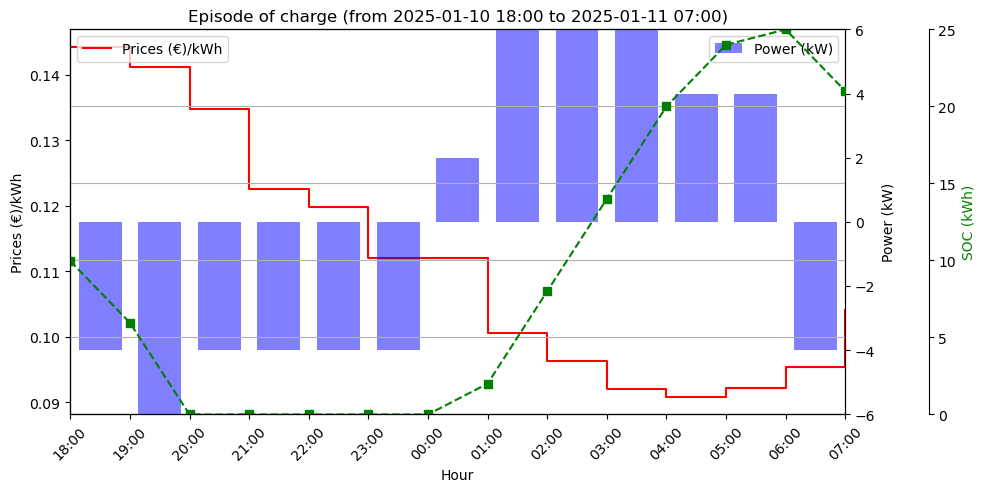

Naive Agent: score=-2.12, final soc: 100%, charging costs: 2.12€


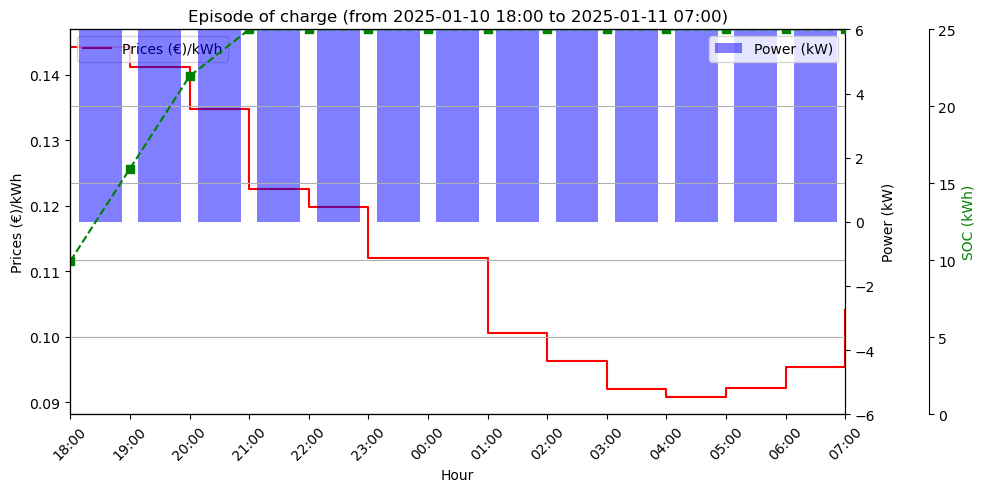

In [13]:
# Showcase the agent vs the naive agent on a specific test episode

date = "2025-01-10"

# DQN Agent
actions, socs, rewards, score = run_episode(agent, env_test, date=date)
print(f"DQN Agent:   score={score:.2f}, final soc: {socs[-1]:.0%}, charging costs: {rewards[-1]-score:.2f}€")
utils.plot_actions_prices(env_test, date=date, actions=actions, socs=socs)


# Naive Agent
actions, socs, rewards, score = run_episode(naive_agent, env_test, date=date)
print(f"Naive Agent: score={score:.2f}, final soc: {socs[-1]:.0%}, charging costs: {rewards[-1]-score:.2f}€")
utils.plot_actions_prices(env_test, date=date, actions=actions, socs=socs)

DQN Agent:   score=-1.50, final soc: 100%, charging costs: 1.50€


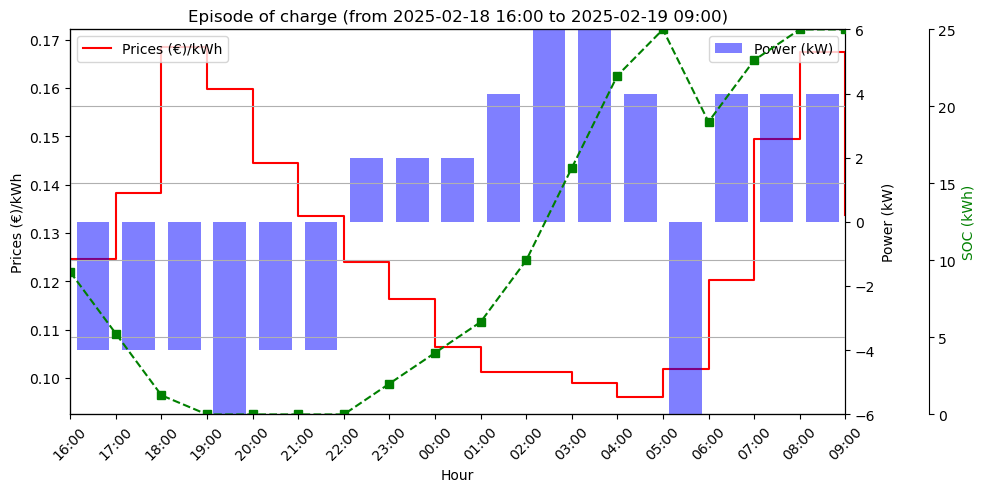

DQN Agent:   score=-1.08, final soc: 100%, charging costs: 1.08€


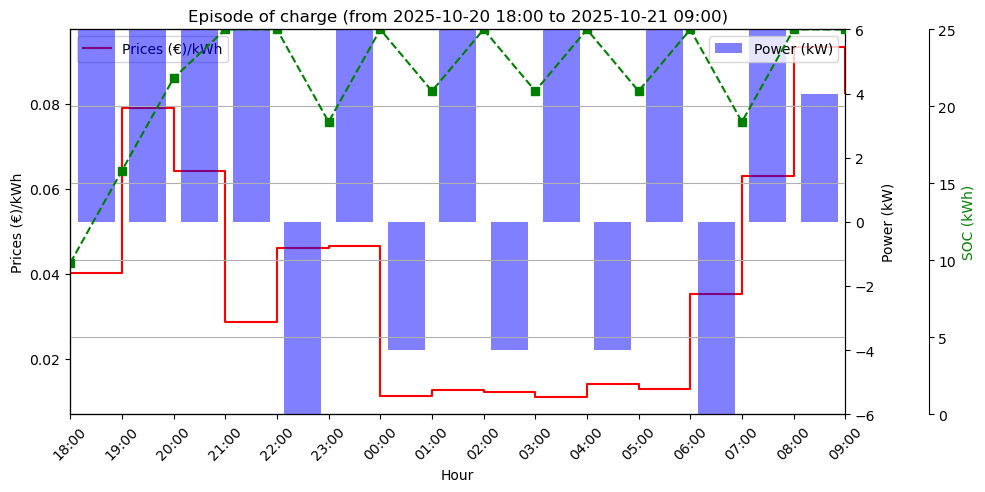

DQN Agent:   score=-0.07, final soc: 100%, charging costs: 0.07€


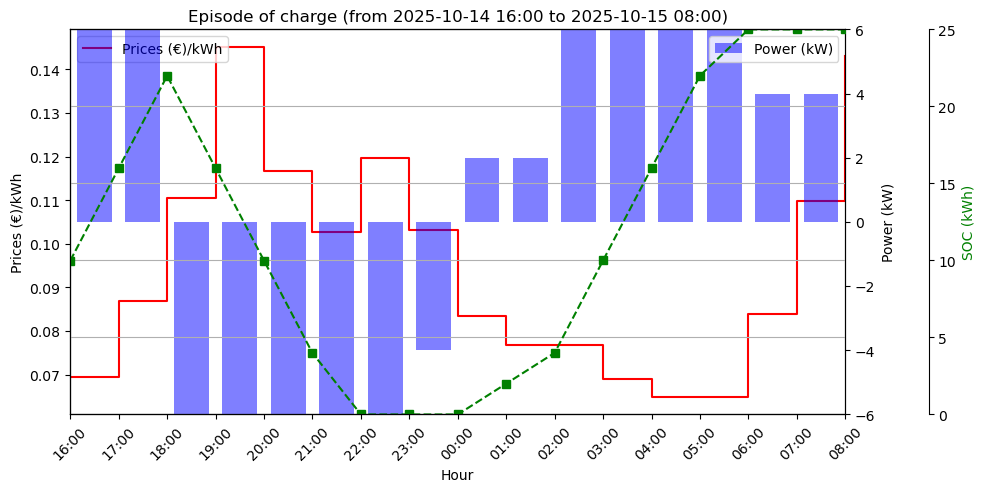

In [14]:
# Show case the agent behavior on random test episodes

for _ in range(3):
    env_test.reset()
    date = env_test.date
    actions, socs, rewards, score = run_episode(agent, env_test, date=date)
    print(f"DQN Agent:   score={score:.2f}, final soc: {socs[-1]:.0%}, charging costs: {rewards[-1]-score:.2f}€")
    utils.plot_actions_prices(env_test, date=date, actions=actions, socs=socs)

## Statistics

In [15]:
# Compute statistics over test episodes

charging_costs = []
naive_charging_costs = []
final_socs = []
naive_final_socs = []
test_dates_list = pd.date_range(start=config.TEST_START_DATE, end=config.TEST_END_DATE, freq='D').strftime('%Y-%m-%d')
for test_date in test_dates_list:
    _, socs, rewards, score = run_episode(agent, env_test, date=test_date)
    _, naive_socs, naive_rewards, naive_score = run_episode(naive_agent, env_test, date=test_date)
    charging_cost =  rewards[-1]-score # Subtracting the final reward (which includes penalties)
    final_soc = socs[-1]
    naive_charging_cost = naive_rewards[-1]-naive_score
    naive_final_soc = naive_socs[-1]
    charging_costs.append(charging_cost)
    final_socs.append(final_soc)
    naive_charging_costs.append(naive_charging_cost)
    naive_final_socs.append(naive_final_soc)


In [16]:
# Print results

def print_agent_results(name, charging_costs, final_socs):
    mean_cost = np.mean(charging_costs)
    std_cost = np.std(charging_costs)
    mean_soc = np.mean(final_socs) * 100
    std_soc = np.std(final_socs) * 100

    print(f"{name:^33}")
    print("-" * 33)
    print(f"Charging cost : {mean_cost:6.2f} €  ± {std_cost:5.2f}")
    print(f"Final SoC     : {mean_soc:6.1f} %  ± {std_soc:5.1f}")
    print()

print_agent_results("DQN Agent", charging_costs, final_socs)
print_agent_results("Naive Agent", naive_charging_costs, naive_final_socs)


            DQN Agent            
---------------------------------
Charging cost :   0.21 €  ±  0.59
Final SoC     :   98.7 %  ±   5.2

           Naive Agent           
---------------------------------
Charging cost :   0.99 €  ±  0.64
Final SoC     :  100.0 %  ±   0.0

